# 02 — Features & EDA

Reads `shots_raw`, engineers the modeling features, and lands `shots_features` —
the table all three models will train on.

Also produces a couple of quick exploratory plots so we can show the audience
the shape of the data before we get into modeling.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
load_dotenv()

try:
    spark
except NameError:
    from databricks.connect import DatabricksSession
    spark = DatabricksSession.builder.serverless().getOrCreate()

UC_CATALOG = os.getenv("UC_CATALOG", "alexander_booth")
UC_SCHEMA  = os.getenv("UC_SCHEMA",  "hockey_xg_mlflow")
SRC = f"{UC_CATALOG}.{UC_SCHEMA}.shots_raw"
DST = f"{UC_CATALOG}.{UC_SCHEMA}.shots_features"
print(f"Source: {SRC}\nTarget: {DST}")

/Users/alexander.booth/miniconda3/envs/demo-env/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py:141: UserWarning: Could not enable SetAllowOversizeProtos, please check the protobuf version.
  warnings.warn("Could not enable SetAllowOversizeProtos, please check the protobuf version.")


Source: alexander_booth.hockey_xg_mlflow.shots_raw
Target: alexander_booth.hockey_xg_mlflow.shots_features


## Feature engineering

The raw table already has `distance_ft` and `angle_deg`, but we add a few more
that give the tree-based models useful signal:

- `distance_sq`, `angle_sq` — nonlinear interactions LR can't recover on its own
- `is_high_danger` — boolean indicator for the slot (≤ 20ft and angle ≤ 30°)
- One-hot encodings for `shot_type` and `strength_state`
- Rebound × distance interaction (rebounds close to net are huge)

In [2]:
from pyspark.sql import functions as F

src = spark.table(SRC)

feat = (
    src
    .withColumn("distance_sq", F.col("distance_ft") ** 2)
    .withColumn("angle_sq",    F.col("angle_deg") ** 2)
    .withColumn("is_high_danger",
                ((F.col("distance_ft") <= 20.0) & (F.col("angle_deg") <= 30.0)).cast("int"))
    .withColumn("rebound_dist", F.col("rebound").cast("int") * F.col("distance_ft"))
    .withColumn("rush_dist",    F.col("rush").cast("int")    * F.col("distance_ft"))
    .withColumn("rebound", F.col("rebound").cast("int"))
    .withColumn("rush",    F.col("rush").cast("int"))
)

# One-hot expansions
SHOT_TYPES = ["wrist", "snap", "slap", "backhand", "tip", "wrap"]
STRENGTHS  = ["5v5", "5v4_pp", "4v5_pk", "4v4", "3v3_ot", "6v5_en", "5v6"]
for st in SHOT_TYPES:
    feat = feat.withColumn(f"st_{st}",   (F.col("shot_type") == st).cast("int"))
for s in STRENGTHS:
    safe = s.replace("/", "_")
    feat = feat.withColumn(f"str_{safe}", (F.col("strength_state") == s).cast("int"))

(feat.write
     .mode("overwrite")
     .option("overwriteSchema", "true")
     .saveAsTable(DST))
print(f"Wrote {spark.table(DST).count():,} rows to {DST}")
spark.table(DST).printSchema()

Wrote 50,000 rows to alexander_booth.hockey_xg_mlflow.shots_features


root
 |-- shot_id: long (nullable = true)
 |-- game_id: long (nullable = true)
 |-- period: long (nullable = true)
 |-- time_in_period_sec: long (nullable = true)
 |-- team_id: long (nullable = true)
 |-- opp_team_id: long (nullable = true)
 |-- player_id: long (nullable = true)
 |-- x: double (nullable = true)
 |-- y: double (nullable = true)
 |-- distance_ft: double (nullable = true)
 |-- angle_deg: double (nullable = true)
 |-- shot_type: string (nullable = true)
 |-- strength_state: string (nullable = true)
 |-- rebound: integer (nullable = true)
 |-- rush: integer (nullable = true)
 |-- prev_event_sec: double (nullable = true)
 |-- goal: long (nullable = true)
 |-- distance_sq: double (nullable = true)
 |-- angle_sq: double (nullable = true)
 |-- is_high_danger: integer (nullable = true)
 |-- rebound_dist: double (nullable = true)
 |-- rush_dist: double (nullable = true)
 |-- st_wrist: integer (nullable = true)
 |-- st_snap: integer (nullable = true)
 |-- st_slap: integer (nullabl

## EDA — quick visuals

Two plots that frame the modeling problem:

1. **Shot map** — heatmap-style scatter of shot locations colored by goal/no-goal.
   You see the slot light up. This is the signal models should pick up.
2. **Goal rate by distance** — bins shots into 5ft buckets and shows the
   monotonically decreasing goal rate. This is the headline relationship.

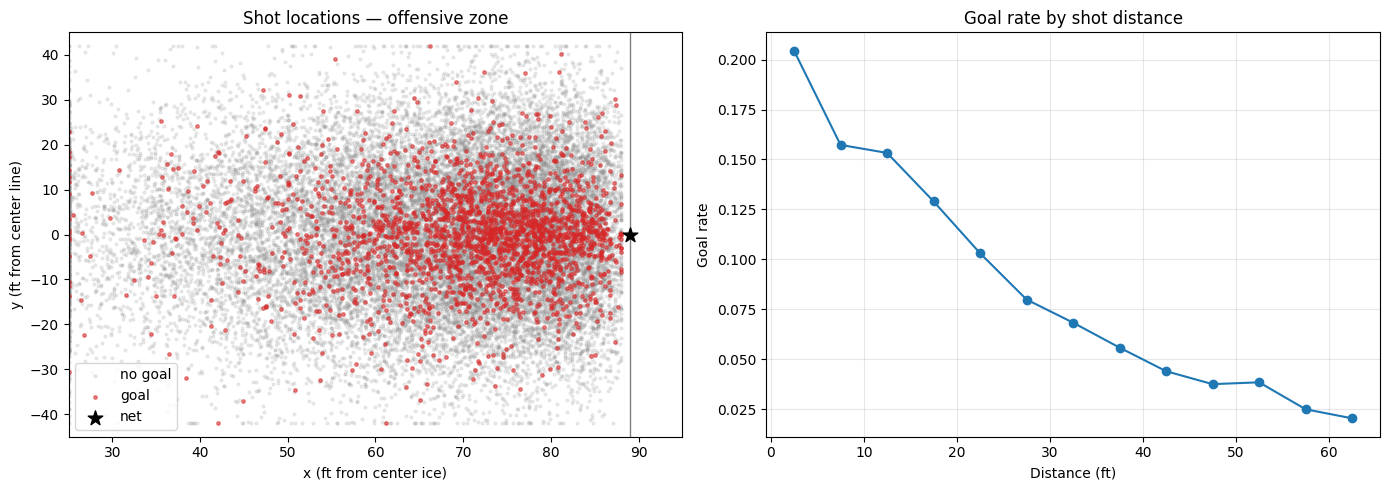

In [3]:
pdf = spark.table(DST).select(
    "x", "y", "distance_ft", "angle_deg", "goal", "shot_type", "strength_state"
).sample(fraction=0.5, seed=1).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
goals    = pdf[pdf["goal"] == 1]
nogoals  = pdf[pdf["goal"] == 0]
ax.scatter(nogoals["x"], nogoals["y"], s=4, alpha=0.15, label="no goal", color="#888")
ax.scatter(goals["x"],   goals["y"],   s=6, alpha=0.55, label="goal",    color="#d62728")
ax.set_xlim(25, 95)
ax.set_ylim(-45, 45)
ax.axvline(89, color="k", lw=1, alpha=0.5)
ax.scatter([89], [0], marker="*", color="k", s=120, zorder=5, label="net")
ax.set_xlabel("x (ft from center ice)")
ax.set_ylabel("y (ft from center line)")
ax.set_title("Shot locations — offensive zone")
ax.legend(loc="lower left")

bins = np.arange(0, 70, 5)
pdf["dist_bin"] = pd.cut(pdf["distance_ft"], bins=bins, include_lowest=True)
rate = pdf.groupby("dist_bin", observed=True)["goal"].mean()
centers = [b.mid for b in rate.index]
axes[1].plot(centers, rate.values, marker="o", color="#1f77b4")
axes[1].set_xlabel("Distance (ft)")
axes[1].set_ylabel("Goal rate")
axes[1].set_title("Goal rate by shot distance")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# Conditional goal rates we expect models to recover
print("Top 5 highest-goal-rate buckets:")
agg = (pdf
       .groupby(["shot_type", "strength_state"], observed=True)["goal"]
       .agg(["mean", "count"])
       .query("count > 30")
       .sort_values("mean", ascending=False)
       .head(5))
print(agg)

Top 5 highest-goal-rate buckets:
                              mean  count
shot_type strength_state                 
tip       6v5_en          0.534884     43
snap      6v5_en          0.500000    112
slap      6v5_en          0.463768     69
wrist     6v5_en          0.433180    217
backhand  6v5_en          0.304348     46
